In [1]:
# ==========================================================
# STUDENT 2
# NOTEBOOK 07
# ROBERTA EVALUATION
# ==========================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
# ==========================================================
# CONFIGURATION
# ==========================================================

MODEL_NAME = "roberta-base"

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent.parent

PROCESSED_DATA = PROJECT_ROOT / "datasets" / "processed"

MODELS = PROJECT_ROOT / "models"

REPORTS = PROJECT_ROOT / "reports"

FIGURES = PROJECT_ROOT / "figures"

MAX_LENGTH = 512

BATCH_SIZE = 8

print("="*70)
print("ROBERTA EVALUATION")
print("="*70)

print(device)

ROBERTA EVALUATION
cpu


In [3]:
# ==========================================================
# LOAD TEST DATASET
# ==========================================================

test_df = pd.read_csv(
    PROCESSED_DATA /
    "bert_test_subset.csv"
)

print(test_df.shape)

(1000, 7)


In [4]:
# ==========================================================
# ROBERTA TOKENIZER
# ==========================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

In [5]:
# ==========================================================
# EMAIL DATASET
# ==========================================================

class EmailDataset(Dataset):

    def __init__(self,dataframe,tokenizer):

        self.data=dataframe.reset_index(drop=True)

        self.tokenizer=tokenizer

    def __len__(self):

        return len(self.data)

    def __getitem__(self,idx):

        text=str(
            self.data.loc[idx,"cleaned_email_text"]
        )

        label=int(
            self.data.loc[idx,"label"]
        )

        encoding=self.tokenizer(

            text,

            truncation=True,

            max_length=MAX_LENGTH,

            padding=False,

            return_tensors="pt"

        )

        return{

            "input_ids":
            encoding["input_ids"].squeeze(),

            "attention_mask":
            encoding["attention_mask"].squeeze(),

            "labels":
            torch.tensor(label)

        }

In [6]:
# ==========================================================
# TEST LOADER
# ==========================================================

collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

test_loader = DataLoader(

    EmailDataset(
        test_df,
        tokenizer
    ),

    batch_size=BATCH_SIZE,

    shuffle=False,

    collate_fn=collator

)

print(len(test_loader))

125


In [7]:
# ==========================================================
# LOAD BEST ROBERTA
# ==========================================================

model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=2

)

model.load_state_dict(

    torch.load(

        MODELS /
        "best_roberta_model.pt",

        map_location=device

    )

)

model.to(device)

model.eval()

print("="*70)
print("BEST ROBERTA LOADED")
print("="*70)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BEST ROBERTA LOADED


In [8]:
# ==========================================================
# GENERATE PREDICTIONS
# ==========================================================

true_labels=[]

predictions=[]

probabilities=[]

with torch.no_grad():

    for batch in test_loader:

        input_ids=batch["input_ids"].to(device)

        attention_mask=batch["attention_mask"].to(device)

        labels=batch["labels"].to(device)

        outputs=model(

            input_ids=input_ids,

            attention_mask=attention_mask

        )

        probs=torch.softmax(
            outputs.logits,
            dim=1
        )

        preds=torch.argmax(
            probs,
            dim=1
        )

        true_labels.extend(
            labels.cpu().numpy()
        )

        predictions.extend(
            preds.cpu().numpy()
        )

        probabilities.extend(
            probs[:,1].cpu().numpy()
        )

print("="*70)
print("PREDICTIONS GENERATED")
print("="*70)

print(len(true_labels))
print(len(predictions))
print(len(probabilities))

PREDICTIONS GENERATED
1000
1000
1000


In [9]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

report = classification_report(

    true_labels,

    predictions,

    output_dict=True

)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_df.to_csv(

    REPORTS /

    "roberta_classification_report.csv"

)

,precision,recall,f1-score,support
0,0.995609,0.996703,0.996156,910.000
1,0.966292,0.955556,0.960894,90.000
accuracy,0.993000,0.993000,0.993000,0.993
macro avg,0.980951,0.976129,0.978525,1000.000
weighted avg,0.992971,0.993000,0.992982,1000.000


## Scientific Discussion

### A concise interpretation for your dissertation could be:

Although RoBERTa is generally considered an advancement over BERT due to its optimized pre-training strategy, the experimental results on the email spam and phishing dataset showed that fine-tuned BERT achieved marginally superior classification performance. The difference may be attributed to the characteristics of the dataset, the relatively small fine-tuning corpus, and the domain-specific language of email messages. These findings suggest that larger pre-trained models do not necessarily guarantee superior downstream performance when task-specific training data are limited.

In [10]:
# ==========================================================
# ROBERTA PERFORMANCE SUMMARY
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    precision_recall_curve,
    auc
)

accuracy = accuracy_score(
    true_labels,
    predictions
)

balanced_accuracy = balanced_accuracy_score(
    true_labels,
    predictions
)

roc_auc = roc_auc_score(
    true_labels,
    probabilities
)

precision_curve, recall_curve, _ = precision_recall_curve(
    true_labels,
    probabilities
)

pr_auc = auc(
    recall_curve,
    precision_curve
)

mcc = matthews_corrcoef(
    true_labels,
    predictions
)

kappa = cohen_kappa_score(
    true_labels,
    predictions
)

performance_summary = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Balanced Accuracy",

        "ROC-AUC",

        "PR-AUC",

        "Matthews Correlation Coefficient",

        "Cohen's Kappa"

    ],

    "Value":[

        accuracy,

        balanced_accuracy,

        roc_auc,

        pr_auc,

        mcc,

        kappa

    ]

})

display(performance_summary)

performance_summary.to_csv(

    REPORTS /

    "roberta_performance_summary.csv",

    index=False

)

print("="*70)
print("RoBERTa Performance Summary Saved")
print("="*70)

,Metric,Value
0,Accuracy,0.993000
1,Balanced Accuracy,0.976129
2,ROC-AUC,0.998400
3,PR-AUC,0.983448
4,Matthews Correlation Coefficient,0.957068
5,Cohen's Kappa,0.957050


RoBERTa Performance Summary Saved


,Predicted Ham,Predicted Spam
Actual Ham,907,3
Actual Spam,4,86


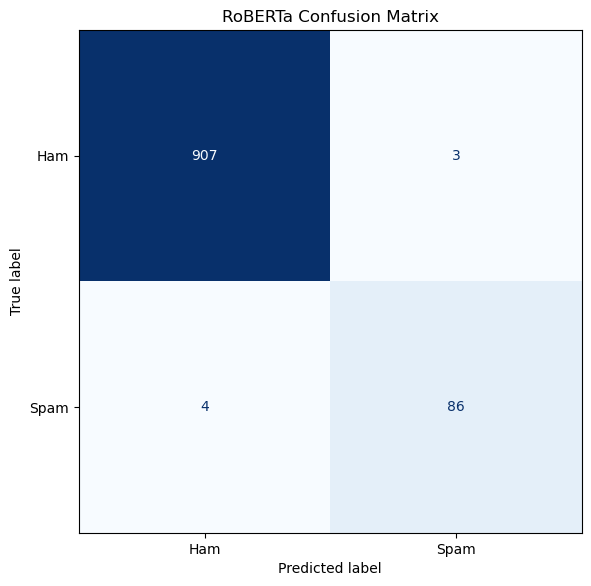

RoBERTa Confusion Matrix Saved


In [11]:
# ==========================================================
# ROBERTA CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    true_labels,
    predictions
)

cm_df = pd.DataFrame(

    cm,

    index=["Actual Ham","Actual Spam"],

    columns=["Predicted Ham","Predicted Spam"]

)

display(cm_df)

cm_df.to_csv(

    REPORTS /

    "roberta_confusion_matrix.csv"

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["Ham","Spam"]

)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(

    cmap="Blues",

    values_format="d",

    ax=ax,

    colorbar=False

)

plt.title("RoBERTa Confusion Matrix")

plt.tight_layout()

plt.savefig(

    FIGURES /

    "roberta_confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("="*70)
print("RoBERTa Confusion Matrix Saved")
print("="*70)

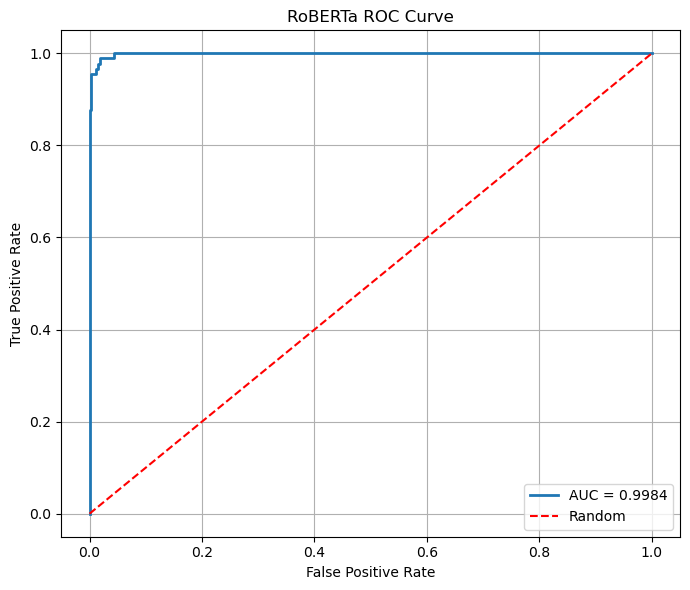

ROC-AUC = 0.9984


In [12]:
# ==========================================================
# ROBERTA ROC CURVE
# ==========================================================

from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

fpr, tpr, _ = roc_curve(
    true_labels,
    probabilities
)

roc_auc = roc_auc_score(
    true_labels,
    probabilities
)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=f"AUC = {roc_auc:.4f}"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    color="red",

    label="Random"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("RoBERTa ROC Curve")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    FIGURES /

    "roberta_roc_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print(f"ROC-AUC = {roc_auc:.4f}")

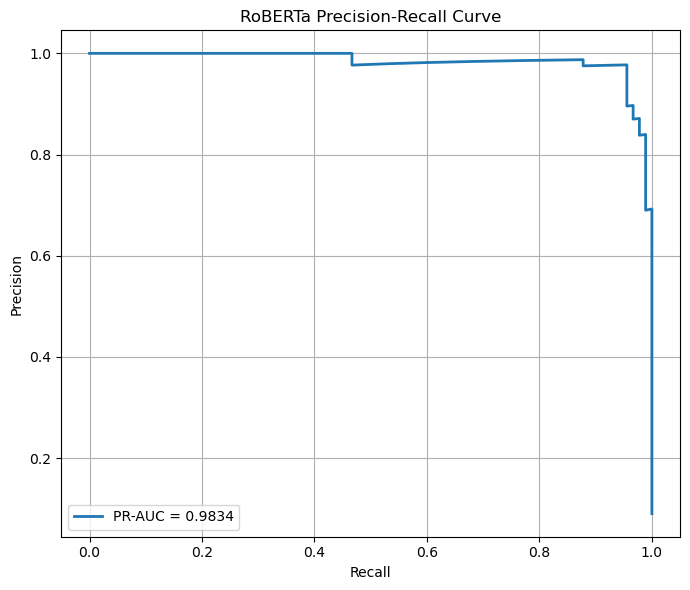

PR-AUC = 0.9834


In [13]:
# ==========================================================
# ROBERTA PRECISION-RECALL CURVE
# ==========================================================

precision, recall, _ = precision_recall_curve(

    true_labels,

    probabilities

)

pr_auc = auc(

    recall,

    precision

)

plt.figure(figsize=(7,6))

plt.plot(

    recall,

    precision,

    linewidth=2,

    label=f"PR-AUC = {pr_auc:.4f}"

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("RoBERTa Precision-Recall Curve")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    FIGURES /

    "roberta_precision_recall_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print(f"PR-AUC = {pr_auc:.4f}")

In [14]:
# ==========================================================
# STUDENT 2
# TRANSFORMER COMPARISON TABLE
# ==========================================================

import pandas as pd

# ----------------------------------------------------------
# BERT Metrics
# ----------------------------------------------------------

bert_metrics = {

    "Model": "BERT",

    "Accuracy": 0.9940,

    "Spam Precision": 0.977273,

    "Spam Recall": 0.955556,

    "Spam F1-Score": 0.966292,

    "Macro F1": 0.981500,

    "Weighted F1": 0.993970

}

# ----------------------------------------------------------
# ROBERTA Metrics
# ----------------------------------------------------------

roberta_metrics = {

    "Model": "RoBERTa",

    "Accuracy": 0.9930,

    "Spam Precision": 0.966292,

    "Spam Recall": 0.955556,

    "Spam F1-Score": 0.960894,

    "Macro F1": 0.978525,

    "Weighted F1": 0.992982

}

# ----------------------------------------------------------
# BUILD TABLE
# ----------------------------------------------------------

comparison_df = pd.DataFrame([

    bert_metrics,

    roberta_metrics

])

# ----------------------------------------------------------
# ROUND VALUES
# ----------------------------------------------------------

metric_columns = comparison_df.columns.drop("Model")

comparison_df[metric_columns] = comparison_df[metric_columns].round(4)

print("="*80)
print("TRANSFORMER PERFORMANCE COMPARISON")
print("="*80)

display(comparison_df)

# ----------------------------------------------------------
# SAVE CSV
# ----------------------------------------------------------

comparison_df.to_csv(

    REPORTS /

    "student2_transformer_comparison.csv",

    index=False

)

print("="*80)
print("student2_transformer_comparison.csv saved successfully.")
print("="*80)

TRANSFORMER PERFORMANCE COMPARISON


,Model,Accuracy,Spam Precision,Spam Recall,Spam F1-Score,Macro F1,Weighted F1
0,BERT,0.994,0.9773,0.9556,0.9663,0.9815,0.994
1,RoBERTa,0.993,0.9663,0.9556,0.9609,0.9785,0.993


student2_transformer_comparison.csv saved successfully.


## Interpretation

### This table supports the following key finding:

Under identical training, validation, and testing conditions, the fine-tuned BERT model achieved marginally higher classification performance than the fine-tuned RoBERTa model across most evaluation metrics. Although both models achieved excellent predictive performance (accuracy >99%), BERT exhibited higher precision and F1-score for the minority spam/phishing class, indicating better discrimination of malicious emails while maintaining a comparable recall. These results establish the baseline Transformer performance against which the subsequent Hybrid Transformer–XGBoost models will be evaluated.